# Машинное обучение

# Тема 7. Бинарная логистическая регрессия

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from scipy.stats import pointbiserialr
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

### Прогноз выгорания сотрудников

[Информация о данных](https://www.kaggle.com/datasets/blurredmachine/are-your-employees-burning-out/data)

| Переменная               | Описание                                                                                     |
|---------------------------|---------------------------------------------------------------------------------------------|
| **Employee ID**           | Уникальный идентификатор сотрудника                                                         |
| **Date of Joining**       | Дата, когда сотрудник присоединился к организации                                           |
| **Gender**                | Пол сотрудника                                                                               |
| **Company Type**          | Тип компании, в которой работает сотрудник                                                 |
| **WFH Setup Available**   | Наличие технической возможности работы из дома у сотрудника                                 |
| **Designation**           | Ранг сотрудника в организации                                                               |
| **Resource Allocation**   | Количество рабочих часов                                                                    |
| **Mental Fatigue Score**  | Уровень ментальной усталости сотрудника                                                     |
| **Burn Rate**             | Уровень выгорания      

Загрузим данные.

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

У нас есть обучающая выборка и тестовая без целевой переменной.

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [4]:
print("Число строк-дубликатов в обучающей выборке:", train.duplicated().sum())

Число строк-дубликатов в обучающей выборке: 0


In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12250 entries, 0 to 12249
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           12250 non-null  object 
 1   Date of Joining       12250 non-null  object 
 2   Gender                12250 non-null  object 
 3   Company Type          12250 non-null  object 
 4   WFH Setup Available   12250 non-null  object 
 5   Designation           12250 non-null  float64
 6   Resource Allocation   12250 non-null  float64
 7   Mental Fatigue Score  12250 non-null  float64
dtypes: float64(3), object(5)
memory usage: 765.8+ KB


In [6]:
print("Число строк-дубликатов в тестовой выборке:", test.duplicated().sum())

Число строк-дубликатов в тестовой выборке: 0


В обучающей выборке есть пропуски, удалим их.

In [7]:
train = train.dropna()

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18590 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           18590 non-null  object 
 1   Date of Joining       18590 non-null  object 
 2   Gender                18590 non-null  object 
 3   Company Type          18590 non-null  object 
 4   WFH Setup Available   18590 non-null  object 
 5   Designation           18590 non-null  float64
 6   Resource Allocation   18590 non-null  float64
 7   Mental Fatigue Score  18590 non-null  float64
 8   Burn Rate             18590 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.4+ MB


### Целевая переменная

Посмотрим на переменную Burn Rate.

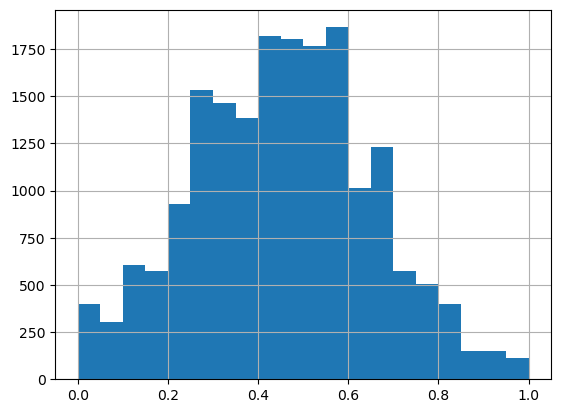

In [9]:
train['Burn Rate'].hist(bins=20);

Распределение похоже на нормальное. Перекодируем Burn Rate в бинарную переменную, чтобы применить бинарную логистическую регрессию для прогнозирования ее значений.

In [10]:
train['Burn_Binary'] = (train['Burn Rate'] > 0.5).astype(int)

In [11]:
train.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Burn_Binary
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16,0
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36,0
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20,0
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52,1
5,fffe3300350037003500,2008-11-26,Male,Product,Yes,2.0,4.0,3.6,0.29,0


In [12]:
train.Burn_Binary.value_counts(normalize='True')

0    0.602205
1    0.397795
Name: Burn_Binary, dtype: float64

Выгоревших около 40%.

### Предикторы

Рассмотрим числовые признаки

In [13]:
train.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Burn_Binary
count,18590.000000,18590.000000,18590.000000,18590.000000,18590.000000
mean,2.179398,4.486552,5.732173,0.452444,0.397795
std,1.133148,2.044848,1.920547,0.197848,0.489456
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.320000,0.000000
50%,2.000000,4.000000,5.900000,0.450000,0.000000
75%,3.000000,6.000000,7.100000,0.590000,1.000000
max,5.000000,10.000000,10.000000,1.000000,1.000000


Они имеют ограничения по значениям и умеренную вариацию.

Рассмотрим их значения по группам целевой переменной.

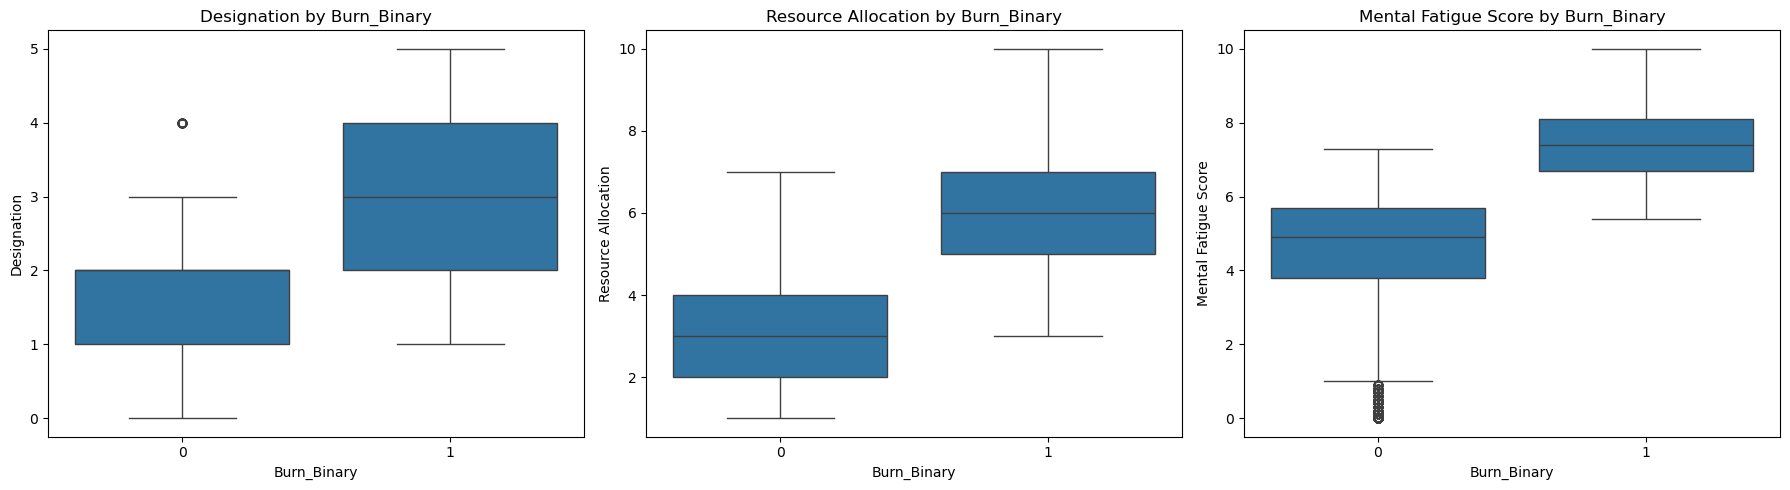

In [14]:
numerical_features = ['Designation', 'Resource Allocation', 'Mental Fatigue Score']

plt.figure(figsize=(18,5))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Burn_Binary', y=col, data=train)
    plt.title(f'{col} by Burn_Binary')

plt.tight_layout()
plt.show()

Видим, что значения признаков отличаются в группах выгоревших и не выгоревших.

Рассчитаем точечно-биссериальную корреляцию между целевой переменной и числовыми признаками.

In [15]:
numerical_vars = ['Designation', 'Resource Allocation', 'Mental Fatigue Score']

print("Точечно-биссериальная корреляция с фактом выгорания:\n")
for col in numerical_vars:
    corr, p_value = pointbiserialr(train['Burn_Binary'], train[col])
    print(f"{col}: коэффициент корреляции = {corr:.3f}, p-value = {p_value:.3e}")

Точечно-биссериальная корреляция с фактом выгорания:

Designation: коэффициент корреляции = 0.592, p-value = 0.000e+00
Resource Allocation: коэффициент корреляции = 0.728, p-value = 0.000e+00
Mental Fatigue Score: коэффициент корреляции = 0.723, p-value = 0.000e+00


Рассмотрим корреляцию между признаками.

In [16]:
train[['Designation', 'Resource Allocation', 'Mental Fatigue Score']].corr(method='kendall')

,Designation,Resource Allocation,Mental Fatigue Score
Designation,1.000000,0.784417,0.537875
Resource Allocation,0.784417,1.000000,0.641390
Mental Fatigue Score,0.537875,0.641390,1.000000


Есть проблема мультиколлинеарности, но, поскольку Designation имеет более слабую корреляцию с целевой переменной, то мы ее удаляем.

Проанализируем категориальные признаки.

In [17]:
categorical_features = ['Gender', 'Company Type', 'WFH Setup Available']

In [18]:
for col in categorical_features:
    print(f"--- {col} ---")
    print(train[col].value_counts(dropna=False)) 
    print("\n")

--- Gender ---
Female    9747
Male      8843
Name: Gender, dtype: int64


--- Company Type ---
Service    12174
Product     6416
Name: Company Type, dtype: int64


--- WFH Setup Available ---
Yes    10030
No      8560
Name: WFH Setup Available, dtype: int64




Группы довольно наполнены. Построим еще таблицы сопряженности с целевой переменной.

In [19]:
target = 'Burn_Binary'

for feature in categorical_features:
    print(f"Таблица сопряженности для {feature}:")
    table = pd.crosstab(train[feature], train[target])
    print(table, "\n")

Таблица сопряженности для Gender:
Burn_Binary     0     1
Gender                 
Female       6754  2993
Male         4441  4402 

Таблица сопряженности для Company Type:
Burn_Binary      0     1
Company Type            
Product       3846  2570
Service       7349  4825 

Таблица сопряженности для WFH Setup Available:
Burn_Binary             0     1
WFH Setup Available            
No                   3385  5175
Yes                  7810  2220 



Проблемы неполноты информации не наблюдается. Для каждого категориального признака осуществляем one-hot кодирование с удалением первой категории.

In [20]:
for col in categorical_features:
    train_dummies = pd.get_dummies(train[col], prefix=col, drop_first=True)
    test_dummies = pd.get_dummies(test[col], prefix=col, drop_first=True)
    
    train = pd.concat([train.drop(columns=[col]), train_dummies], axis=1)
    test = pd.concat([test.drop(columns=[col]), test_dummies], axis=1)

In [21]:
train

,Employee ID,Date of Joining,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,Burn_Binary,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,fffe32003000360033003200,2008-09-30,2.0,3.0,3.8,0.16,0,0,1,0
1,fffe3700360033003500,2008-11-30,1.0,2.0,5.0,0.36,0,1,1,1
3,fffe32003400380032003900,2008-11-03,1.0,1.0,2.6,0.20,0,1,1,1
4,fffe31003900340031003600,2008-07-24,3.0,7.0,6.9,0.52,1,0,1,0
5,fffe3300350037003500,2008-11-26,2.0,4.0,3.6,0.29,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
22743,fffe3300390030003600,2008-12-15,1.0,3.0,6.0,0.48,0,0,0,1
22744,fffe32003500370033003200,2008-05-27,3.0,7.0,6.2,0.54,1,1,0,0
22746,fffe33003000350031003800,2008-01-19,3.0,6.0,6.7,0.59,1,0,0,1
22748,fffe33003300320036003900,2008-01-10,2.0,5.0,5.9,0.52,1,0,1,0


In [22]:
test

,Employee ID,Date of Joining,Designation,Resource Allocation,Mental Fatigue Score,Gender_Male,Company Type_Service,WFH Setup Available_Yes
0,fffe31003300390039003000,2008-12-10,2.0,5.0,7.7,0,1,0
1,fffe31003300310037003800,2008-08-14,1.0,2.0,5.2,0,0,1
2,fffe33003400380035003900,2008-11-13,1.0,3.0,5.9,1,0,1
3,fffe3100370039003200,2008-02-07,3.0,6.0,4.6,0,1,0
4,fffe32003600390036003700,2008-07-17,2.0,5.0,6.4,0,0,0
...,...,...,...,...,...,...,...,...
12245,fffe3900310034003700,2008-10-02,1.0,2.0,6.1,0,1,1
12246,fffe32003600330034003000,2008-03-31,2.0,4.0,5.9,0,0,1
12247,fffe31003800340039003000,2008-02-12,4.0,7.0,9.6,1,1,0
12248,fffe32003600380031003800,2008-02-06,3.0,6.0,6.7,1,1,0


Удаляем ненужные признаки, отделяем целевую переменную и предикторы.

In [23]:
drop_cols_train = ['Employee ID', 'Date of Joining', 'Burn Rate', 'Burn_Binary', 'Designation']

y_train = train['Burn_Binary']
X_train = train.drop(columns=drop_cols_train)

In [24]:
drop_cols_test = ['Employee ID', 'Date of Joining', 'Designation']

X_test = test.drop(columns=drop_cols_test)

Делим train на train и validation.

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

Train: (14872, 5), Validation: (3718, 5)


Обучаем бинарную логистическую регрессию.

In [26]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Прогнозируем на train для оценки модели

In [27]:
y_train_pred = model.predict(X_train)

Метрики на обучающей выборке

Точность: 0.940761161915008 

Матрица ошибок:
[[8519  430]
 [ 451 5472]]

Расшифровка:
TN (True Negative)  — правильно предсказали 0: 8519
FP (False Positive) — предсказали 1, но на самом деле 0: 430
FN (False Negative) — предсказали 0, но на самом деле 1: 451
TP (True Positive)  — правильно предсказали 1: 5472

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      8949
           1       0.93      0.92      0.93      5923

    accuracy                           0.94     14872
   macro avg       0.94      0.94      0.94     14872
weighted avg       0.94      0.94      0.94     14872

ROC-AUC: 0.987


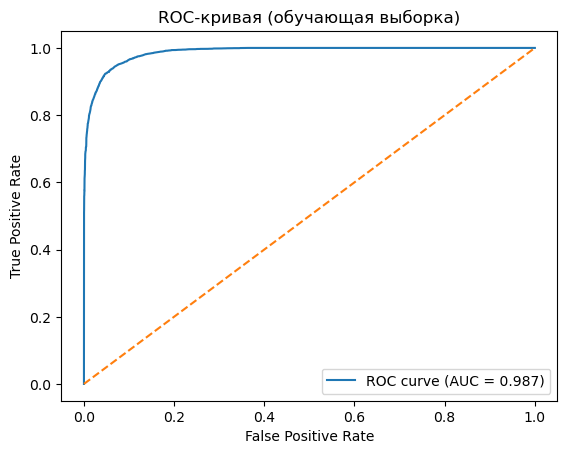

In [28]:
print("Метрики на обучающей выборке\n")

print("Точность:", accuracy_score(y_train, y_train_pred), '\n')

cm = confusion_matrix(y_train, y_train_pred)
print("Матрица ошибок:")
print(cm)

print("\nРасшифровка:")
print(f"TN (True Negative)  — правильно предсказали 0: {cm[0,0]}")
print(f"FP (False Positive) — предсказали 1, но на самом деле 0: {cm[0,1]}")
print(f"FN (False Negative) — предсказали 0, но на самом деле 1: {cm[1,0]}")
print(f"TP (True Positive)  — правильно предсказали 1: {cm[1,1]}")

print("\nClassification Report:\n", classification_report(y_train, y_train_pred))

# ROC-AUC
y_proba_train = model.predict_proba(X_train)[:, 1]
roc_auc_train = roc_auc_score(y_train, y_proba_train)
print(f"ROC-AUC: {roc_auc_train:.3f}")

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_train, y_proba_train)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_train:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая (обучающая выборка)")
plt.legend()
plt.show()

Метрики на валидационной выборке

Точность: 0.9376008606777838 

Матрица ошибок:
[[2133  113]
 [ 119 1353]]

Расшифровка:
TN (True Negative)  — правильно предсказали 0: 2133
FP (False Positive) — предсказали 1, но на самом деле 0: 113
FN (False Negative) — предсказали 0, но на самом деле 1: 119
TP (True Positive)  — правильно предсказали 1: 1353

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      2246
           1       0.92      0.92      0.92      1472

    accuracy                           0.94      3718
   macro avg       0.94      0.93      0.93      3718
weighted avg       0.94      0.94      0.94      3718

ROC-AUC: 0.987


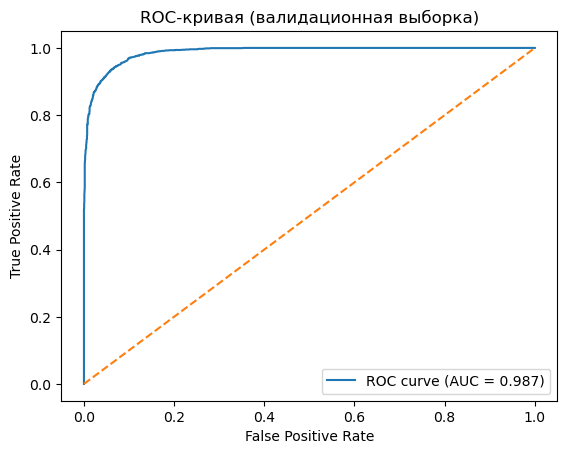

In [29]:
y_val_pred = model.predict(X_val)

print("Метрики на валидационной выборке\n")

print("Точность:", accuracy_score(y_val, y_val_pred), '\n')

cm = confusion_matrix(y_val, y_val_pred)
print("Матрица ошибок:")
print(cm)

print("\nРасшифровка:")
print(f"TN (True Negative)  — правильно предсказали 0: {cm[0,0]}")
print(f"FP (False Positive) — предсказали 1, но на самом деле 0: {cm[0,1]}")
print(f"FN (False Negative) — предсказали 0, но на самом деле 1: {cm[1,0]}")
print(f"TP (True Positive)  — правильно предсказали 1: {cm[1,1]}")

print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

# ROC-AUC
y_val_proba = model.predict_proba(X_val)[:, 1]
roc_auc_val = roc_auc_score(y_val, y_val_proba)
print(f"ROC-AUC: {roc_auc_val:.3f}")

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая (валидационная выборка)")
plt.legend()
plt.show()

Делаем прогноз на тестовых данных.

In [30]:
test['Burn_Pred'] = model.predict(X_test)
print(test[['Employee ID', 'Burn_Pred']].head(10))

                Employee ID  Burn_Pred
0  fffe31003300390039003000          1
1  fffe31003300310037003800          0
2  fffe33003400380035003900          0
3      fffe3100370039003200          0
4  fffe32003600390036003700          1
5      fffe3600390032003200          1
6      fffe3600370032003200          0
7  fffe32003900390030003000          1
8      fffe3100370031003000          1
9  fffe31003500320037003600          0


Рассмотрим подробнее коэффициенты регрессии.

In [31]:
print("\nКоэффициенты модели:\n")

for feature, coef in zip(X_train.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

print(f"\nСвободный член (intercept): {model.intercept_[0]:.4f}")


Коэффициенты модели:

Resource Allocation: 1.3658
Mental Fatigue Score: 2.6493
Gender_Male: 0.7134
Company Type_Service: -0.1524
WFH Setup Available_Yes: -1.6735

Свободный член (intercept): -22.9655


Рассчитаем на их основе отношения шансов и предельные эффекты.

In [32]:
# создаём таблицу
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_[0],
})

# добавляем OR
coef_df["odds_ratio (exp(coef))"] = np.exp(coef_df["coef"])

# считаем среднюю вероятность
p_mean = model.predict_proba(X_train)[:, 1].mean()

# добавляем marginal effect
coef_df["marginal_effect"] = coef_df["coef"] * p_mean * (1 - p_mean)

# сортировка по важности (по модулю коэффициента)
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values(by="abs_coef", ascending=False)

coef_df = coef_df.drop(columns=["abs_coef"])

# сбрасываем индекс
coef_df = coef_df.reset_index(drop=True)

coef_df

,feature,coef,odds_ratio (exp(coef)),marginal_effect
0,Mental Fatigue Score,2.649288,14.143959,0.634902
1,WFH Setup Available_Yes,-1.673548,0.187580,-0.401066
2,Resource Allocation,1.365785,3.918797,0.327310
3,Gender_Male,0.713385,2.040887,0.170963
4,Company Type_Service,-0.152431,0.858618,-0.036530


- OR удобен для объяснения конкретных единиц изменения, но не для ранжирования влияния между признаками.

- Для интерпретации влияния признака на вероятность наступления события предельные эффекты дают более наглядный результат.

- Для чистой feature importance (сравнение влияния признаков между собой) наиболее корректно использовать  стандартизированные коэффициенты.


**Mental Fatigue Score**
- коэффициент положительный, значит, увеличение ментальной усталости сильно повышает вероятность выгорания.
- повышение показателя ментальной усталости на единицу увеличивает шансы выгорания более чем в 14 раз.
- вероятность выгорания увеличивается на 63.5 п.п. при увеличении показателя усталости на единицу.

**Gender_Male**
- коэффициент положительный, значит мужчины имеют большую вероятность выгореть.
- шансы выгорания у мужчин почти в 2 раза выше.
- у мужчин вероятность выгорания выше на 17.1 п.п.

Выведем статистическую значимость коэффициентов.

In [33]:
# для получения p-value через statsmodels
X_sm = sm.add_constant(X_train)
model_sm = sm.Logit(y_train, X_sm).fit(disp=False)

p_values = model_sm.pvalues

# создаём таблицу
summary_df = pd.DataFrame({
    "feature": p_values.index,
    "p_value": p_values.values
})

# сортировка по возрастанию p-value (самые значимые сверху)
summary_df = summary_df.sort_values(by="p_value", ascending=True)

# сбрасываем индекс
summary_df = summary_df.reset_index(drop=True)

# округление
summary_df = summary_df.round(4)

summary_df

,feature,p_value
0,const,0.0000
1,Mental Fatigue Score,0.0000
2,Resource Allocation,0.0000
3,WFH Setup Available_Yes,0.0000
4,Gender_Male,0.0000
5,Company Type_Service,0.0634


Все признаки статистически значимо влияют на выгорание кроме типа компании.

Рассчитаем стандартизированные коэффициенты.

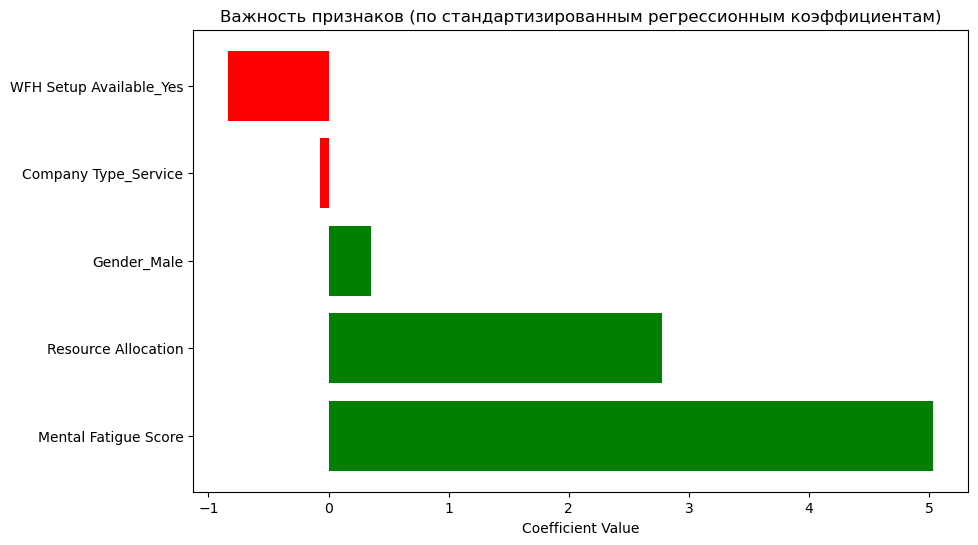

In [34]:
# Стандартизируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Обучаем логистическую регрессию
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Важность признаков 
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})
feature_importance = feature_importance.sort_values(by='coefficient', ascending=True)

# Визуализация 
plt.figure(figsize=(10,6))
colors = ['red' if c < 0 else 'green' for c in feature_importance['coefficient']]
plt.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Coefficient Value')
plt.title('Важность признаков (по стандартизированным регрессионным коэффициентам)')
plt.show()

Прежде всего на выгорание влияет ментальная усталость, далее перегруженность, затем наличие технической возможности работы из дома. 

### Регуляризация

Применим регуляризацию и сравним метрики качества моделей и их коэффициенты.

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

models = {
    "No_reg": LogisticRegression(penalty=None, max_iter=1000),
    "L1": LogisticRegression(penalty='l1', solver='saga', max_iter=1000),
    "L2": LogisticRegression(penalty='l2', max_iter=1000),
    "ElasticNet": LogisticRegression(
        penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000
    )
}

results = []
coef_df = pd.DataFrame(index=X_train.columns)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "auc": roc_auc_score(y_val, y_proba)
    })
    
    coef_df[name] = model.coef_[0]

metrics_df = pd.DataFrame(results).set_index("model")

print("\nМетрики на валидационной выборке")
print(metrics_df.round(3))

print("\nКоэффициенты моделей")
print(coef_df.round(3))


Метрики на валидационной выборке
            accuracy  precision  recall     f1    auc
model                                                
No_reg         0.938      0.923   0.919  0.921  0.987
L1             0.938      0.923   0.919  0.921  0.987
L2             0.938      0.923   0.918  0.921  0.987
ElasticNet     0.938      0.923   0.919  0.921  0.987

Коэффициенты моделей
                         No_reg     L1     L2  ElasticNet
Resource Allocation       2.805  2.794  2.771       2.782
Mental Fatigue Score      5.127  5.105  5.030       5.067
Gender_Male               0.359  0.357  0.357       0.357
Company Type_Service     -0.073 -0.071 -0.072      -0.072
WFH Setup Available_Yes  -0.842 -0.838 -0.833      -0.836


Сравнение моделей показало, что применение различных видов регуляризации (L1, L2 и Elastic Net) практически не повлияло на качество классификации: все модели продемонстрировали одинаковые значения accuracy, precision, recall, F1-score и AUC. Это свидетельствует о том, что исходная модель логистической регрессии уже обладает хорошей обобщающей способностью и не склонна к переобучению. 

Коэффициенты моделей с регуляризацией незначительно уменьшились по сравнению с моделью без регуляризации, при этом L1-регуляризация не занулила ни один из признаков, что указывает на их информативность. 

В целом, различия между моделями минимальны, а значит, выбор конкретного типа регуляризации в данном случае не является критичным и не приводит к улучшению качества модели.